In [4]:
# Custom tools
from modules.instance import Instance
from modules.analyzer import TrendAnalyzer
instance = Instance()

Enter symbol:BHP


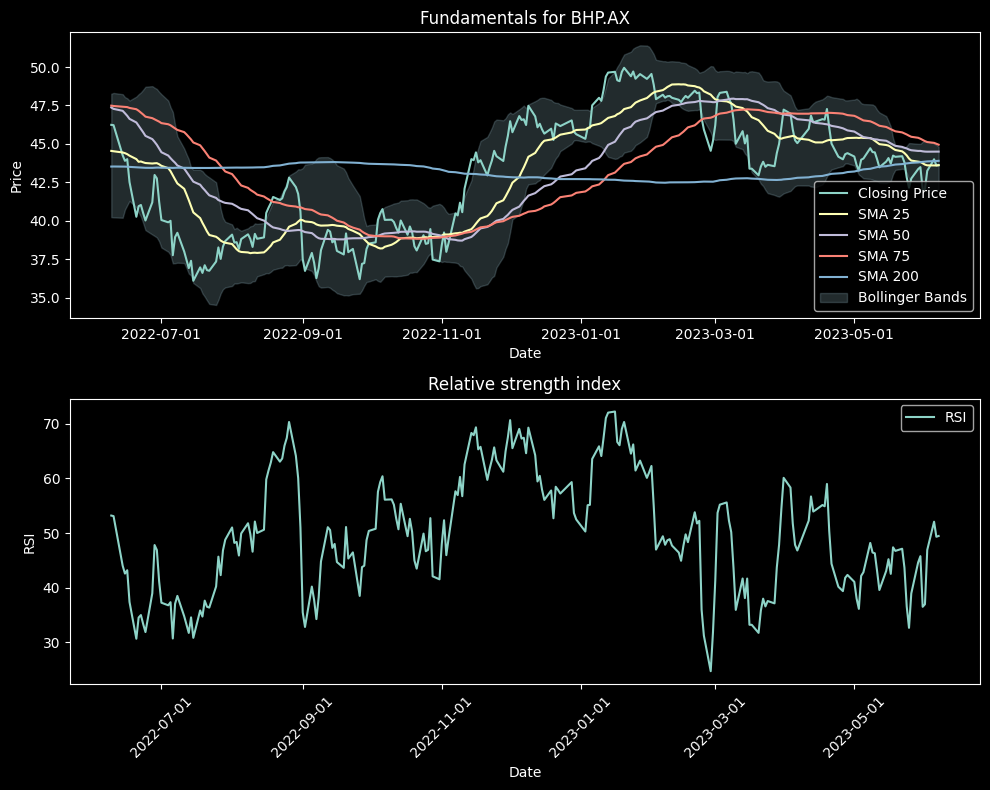

In [5]:
ticker = input("Enter symbol:")
table_name = ticker+'.AX'

# Use the premade classes to perform analysis
data = instance.datastore.get_table_data(table_name)

# Analyzer class can generate charts and calculate_technical_indicators (rsi,sma,bb) 
analyzer = TrendAnalyzer(table_name, data)

# Generate a basic fundamentals chart (auto filtered to 90 days)
analyzer.fundamentals_chart(filter=365) #1 year, takes days. Is defaulting to orders none
# analyzer.fundamentals_chart(orders = True) # default to a 90d swing view, orders true = has buy and sell columns to plot

In [12]:
from strategies import Strategy
import pandas as pd
import backtrader as bt

# Perform trend analysis and merge the results with data
ticker = input("Enter symbol:")
table_name = ticker+'.AX'

class Feed(bt.feeds.PandasData):
    lines = ('Open', 'High', 'Low', 'Close', 'Volume')

# Create an instance of your custom data feed
data = Feed(dataname=instance.datastore.get_table_data(table_name))
print(data)

# Test a strategy
cerebro = bt.Cerebro()
cerebro.addstrategy(Strategy)

# Add your data feed (replace with your actual data)
cerebro.adddata(data)

# Set initial capital and commission
cerebro.broker.setcash(100000.0)
cerebro.broker.setcommission(commission=0.001)

# Run the backtest
cerebro.run()

# Analyze the results
cerebro.plot()

Enter symbol:BHP


AttributeError: 'AutoInfoClass_LineRoot_LineMultiple_LineSeries_Dat' object has no attribute 'Open'

In [ ]:
''' 
def main():
    pass
if __name__ == '__main__':
    main()
'''